## create local automata

In [3]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

def creare_random_connected_graph(n_nodes, n_edges):
    # Generate a random graph
    G = nx.Graph()

    # Add nodes
    G.add_nodes_from(range(n_nodes))

    # Add random edges
    while G.number_of_edges() < n_edges:
        u = random.randint(0, n_nodes-1)
        v = random.randint(0, n_nodes-1)
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
    # Check if graph is connected
    while not nx.is_connected(G):
        # Add random edges until connected
        # get disconnected node
        disconnected_node = random.choice(list(nx.isolates(G)))
        # get random node
        random_node = random.choice(list(G.nodes()))
        if disconnected_node != random_node and not G.has_edge(disconnected_node, random_node):
            G.add_edge(disconnected_node, random_node)
    return G


colors = [np.random.rand(3,) for _ in range(5)]
graphs = []
pos_list = []
for _ in range(5):
    G = creare_random_connected_graph(5, 7)
    graphs.append(G)
    pos_list.append(nx.spring_layout(G))

## prepare states

In [4]:

numbers = np.random.randint(0, 5, size=5)
target_automaton = 0
target_state = 0

states = []
for i in range(5):
    states.append({'goal': {'target_automaton': (target_automaton+i)%5, 'target_state': (target_state+i)%5},
                   'local_states': numbers})
len(states)
states

[{'goal': {'target_automaton': 0, 'target_state': 0},
  'local_states': array([4, 0, 1, 3, 4])},
 {'goal': {'target_automaton': 1, 'target_state': 1},
  'local_states': array([4, 0, 1, 3, 4])},
 {'goal': {'target_automaton': 2, 'target_state': 2},
  'local_states': array([4, 0, 1, 3, 4])},
 {'goal': {'target_automaton': 3, 'target_state': 3},
  'local_states': array([4, 0, 1, 3, 4])},
 {'goal': {'target_automaton': 4, 'target_state': 4},
  'local_states': array([4, 0, 1, 3, 4])}]

## animate

/home/jan/miniconda3/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


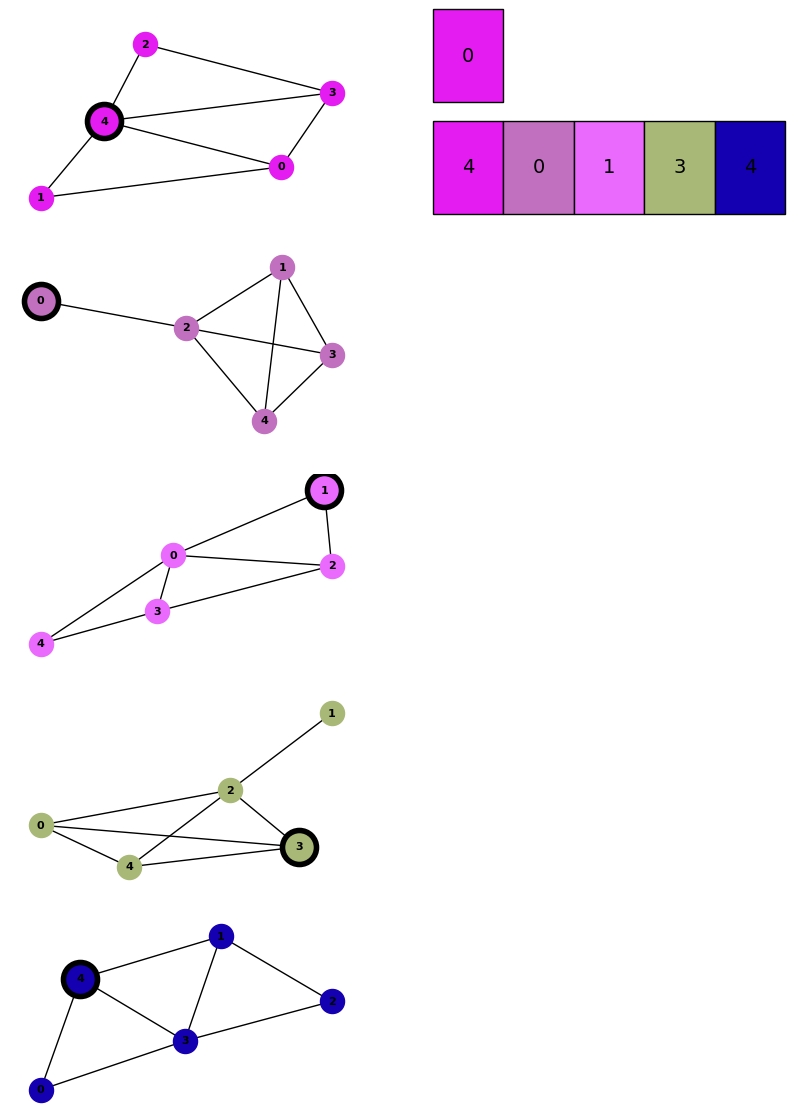

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with custom gridspec
fig = plt.figure(figsize=(10, 14))
gs = plt.GridSpec(5, 2, figure=fig)





# Function to update the frame
def update(frame,states):
    state = states[frame]
    current_goal = state['goal']
    target_state = current_goal['target_state']
    target_automaton = current_goal['target_automaton']

    numbers = state['local_states']
    # Clear the figure
    fig.clear()
    # Create 5 random graphs in the first column
    for i in range(5):
        local_state = numbers[i]
        ax = fig.add_subplot(gs[i, 0])
        # Generate random graph
        G = graphs[i]
        
        # Draw the graph
        pos = pos_list[i]
        
        # Draw all nodes
        nx.draw(G, pos, ax=ax, with_labels=True,
                node_color=colors[i], node_size=300,
                font_size=8, font_weight='bold')
        
        # Highlight the node corresponding to local_state with thicker border
        nx.draw_networkx_nodes(G, pos, ax=ax,
                            nodelist=[local_state],
                            node_color=colors[i],
                            node_size=600,
                            edgecolors='black',
                            linewidths=4)
        #ax.set_title(f'Random Graph {i+1}')

    # Create 1 subplot spanning all rows in second column
    ax = fig.add_subplot(gs[:1, 1])

    ax.clear()
    ax.axis('off')
    # Create vector of 5 random numbers
    top_row = [str(target_state)]
    top_colors = [colors[target_automaton]]
    # Create sample data for tables
    table1 = ax.table(cellText=[numbers],
                    cellColours=[colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 0.5])

    table2 = ax.table(cellText=[top_row],
                    cellColours=[top_colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0.2*target_automaton%5, 0.6, 0.2, 0.5]) # prvni souradnice ovlivnuje umisteni vrchni bunky

    # Style the tables
    table1.set_fontsize(14)
    table2.set_fontsize(14)


# Create animation
anim = animation.FuncAnimation(fig, update, frames=5,
                               fargs=(states,) ,
                             interval=1000, repeat=True)
anim.save('search_animation.gif', writer='pillow')

